# init
---

In [1]:
#### mv packages ####
import modules.data as d
import modules.model as m
import modules.pooling as p
import modules.train as t
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device()#['cuda:1', 'cuda:0'])
# device, generator = u.Devices().set_device('cpu')

#### data ####
brca = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=True, 
    log_transform=True,
    scale_method='standard',

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
_dataset = d.GraphDataset(brca)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:1

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:1)
# edge_index               (2, 32798)               Tensor (cuda:1)
# edge_attr                (32798, 16)              Tensor (cuda:1)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:1)
# x                        (562, 4383, 1)           Tensor (cuda:1)
# y                        (562,)                   Tensor (cuda:1)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


In [2]:
#### convenience variables ####
_embedding_size = 64

# from mask (init)
_mask = brca.mask
_num_nodes, _num_sets = _mask.shape

# from batch (forward)
_batch_size = int(_batch.x.shape[0]/_num_nodes)
_num_node_features = _batch.x.shape[1] # or brca.num_node_features

# transformer re-attempt
---

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from modules.model import get_layers, SequentialModel
from modules.pooling import SetPooling
from torch import Tensor
from torch_geometric.nn import MessagePassing, GCNConv
from typing import Literal, Optional, Union

import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
def handle_transformer_dims(embed_dim:Optional[int], head_dim:Optional[int], num_heads:int):
    # none specified; assert error
    assert (embed_dim is not None) or (head_dim is not None), 'one of [embed_dim, head_dim] must be specified'

    # both specified; lin_out reshapes head to embed
    if (embed_dim is not None) and (head_dim is not None):
        assert embed_dim // num_heads == head_dim, 'transformer dims incompatible, (embed_dim // num_heads == head_dim) must be true'
        return embed_dim, head_dim

    # embed_dim specified; head = embed / num_heads
    elif embed_dim is not None:
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'
        head_dim = embed_dim // num_heads

    # head_dim specified; embed = head * num_heads
    elif head_dim is not None:
        embed_dim = head_dim * num_heads

    return embed_dim, head_dim

In [5]:
_mask.T.shape

torch.Size([305, 4383])

In [6]:
class LazyAttnSetPooling(nn.Module):
    def __init__(self, in_features, mask:Tensor, pool_method:Literal['add','mean']='add', embed_dim:int=None, head_dim:int=None, num_heads:int=1, dropout:float=0.0, *args, **kwargs):
        '''
        mask in (nodes, sets)
        '''
        super().__init__(*args, **kwargs)
        self.mask = mask.T # convert to (sets, nodes) for attn_mask in (q, kv)
        self.num_sets, self.num_nodes = self.mask.shape

        self.pool_method = pool_method
        self.set_counts = self.mask.sum(dim=1, keepdim=True).clamp(min=1) # sum across nodes; in (sets, 1)
        
        embed_dim, _ = handle_transformer_dims(embed_dim, head_dim, num_heads)

        self.qkv = nn.Linear(
            in_features=in_features,
            out_features=3*embed_dim
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x:Tensor):
        '''
        x in (b*n,f) or (b,n,F)
        attn_mask in (n, s) or (b * heads, n, s); True is d
        '''
        # convert x to (b,n,F) if applicable
        if x.dim() == 2:
            batch_size = int(x.shape[0]//self.num_nodes)
            x = x.view(batch_size, self.num_nodes, -1)

        # calculate qkv
        q, k, v = self.qkv(x).chunk(3, dim=-1) # each in (b,n,E)

        # pool q
        q = self.mask @ q # (b,s,n) @ (b,n,E) -> (b,s,E)
        if self.pool_method == 'mean':
            q = q / self.set_counts

        # get attn_mask
        attn_mask = (self.mask == 0)

        # get output
        attn_output, _ = self.attn(
            query = q,
            key = k,
            value = v,
            attn_mask = attn_mask,
            need_weights = False
        )

        return attn_output # (b,s,E)
        


In [7]:
lasp = LazyAttnSetPooling(
    in_features=brca.num_node_features,
    mask=brca.mask,
    head_dim=_embedding_size
)

_set_emb = lasp(_batch.x)
print(_set_emb.shape)

torch.Size([64, 305, 64])


---

In [8]:
class AttnGlobalPooling(nn.Module):
    def __init__(self, embed_dim:int=None, head_dim:int=None, num_heads:int=1, dropout:float=0.0, *args, **kwargs):
        super().__init__(*args, **kwargs)

        embed_dim, _ = handle_transformer_dims(embed_dim, head_dim, num_heads)

        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, x:Tensor):
        '''
        x in (b,n,E) or (b,s,E)
        '''
        batch_size = x.shape[0]

        # expand cls
        cls = self.cls_token.expand(batch_size, -1, -1)

        # get cross attn, in (b,1,E)
        attn_output, _ = self.attn(
            query = cls,
            key = x,
            value = x,
            need_weights = False
        )

        # squeeze (b,1,E) -> (b,E)
        attn_output = attn_output.squeeze(1)

        return attn_output

        

In [9]:
agp = AttnGlobalPooling(head_dim=_embedding_size)

_samp_emb = agp(_set_emb)
print(_samp_emb.shape)

torch.Size([64, 64])


---

In [10]:
class SimpleDecoder(nn.Module):
    def __init__(
        self, 
        out_channels:int, 
        layer_class,
        layer_kwargs:dict={}, 
        hidden_dims:list[int, None]=[], 
        act_fn=nn.LeakyReLU(), 
        end_fn=None, 

        embed_dim:int=None,
        head_dim:int=None, 
        num_heads:int=1,

        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        embed_dim, _ = handle_transformer_dims(embed_dim, head_dim, num_heads)

        self.lin = SequentialModel(
            in_channels=embed_dim,
            out_channels=out_channels,
            layer_class=layer_class,
            layer_kwargs=layer_kwargs,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            end_fn=end_fn
        )


    def forward(self, z:Tensor):
        '''
        samp_emb (z) in (b,E)
        '''
        x_recon = self.lin(z)
        return x_recon

In [11]:
dec = SimpleDecoder(
    head_dim=_embedding_size,
    out_channels=brca.num_nodes,
    layer_class=nn.Linear
)

print(_batch.x.shape)
dec(_samp_emb).shape

torch.Size([280512, 1])


torch.Size([64, 4383])

## encoder-only test (simple decoder)
---

In [12]:
class SimpleAutoencoder(nn.Module):
    def __init__(
        self,
        # required
        in_features:int,
        out_features:int,
        mask:Tensor, # (n,s)
        decoder_class,

        # transformer
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,
        dropout:float=0.0,

        # other
        pool_method:Literal['add','mean'] = 'add',
        decoder_dims:list[int, None]=[],
        decoder_kwargs:dict={},
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.num_nodes = mask.shape[0]
        embed_dim, head_dim = handle_transformer_dims(embed_dim, head_dim, num_heads)

        self.set_pooling = LazyAttnSetPooling(
            in_features=in_features,
            mask=mask,
            pool_method=pool_method,
            embed_dim=embed_dim,
            head_dim=head_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.global_pooling = AttnGlobalPooling(
            embed_dim=embed_dim,
            head_dim=head_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.decoder = SimpleDecoder(
            out_channels=out_features,
            layer_class=decoder_class,
            hidden_dims=decoder_dims,
            embed_dim=embed_dim,
            head_dim=head_dim,
            num_heads=num_heads,
            **decoder_kwargs
        )

    def forward(self, x:Tensor, *args, **kwargs):
        batch_size = int(x.shape[0]/self.num_nodes)

        set_emb = self.set_pooling(x)
        z = self.global_pooling(set_emb)
        x_recon = self.decoder(z)

        return x_recon.view(batch_size * self.num_nodes, 1)

In [13]:
simple_ae = SimpleAutoencoder(
    in_features=brca.num_node_features,
    out_features=brca.num_nodes,
    mask=brca.mask,
    decoder_class=nn.Linear,
    head_dim=8,
    num_heads=2
)

simple_ae(_batch.x).shape

torch.Size([280512, 1])

In [14]:
_batch.x

tensor([[-0.5971],
        [-0.4030],
        [ 0.7413],
        ...,
        [ 0.2908],
        [-0.2381],
        [ 0.2268]], device='cuda:1')

In [15]:
from modules.train import Loader, Trainer

class SimpleReconstructionTrainer(Trainer):
    def __init__(self, alpha:float=0.5, *args, **kwargs):
        self.alpha = alpha
        super().__init__(*args, **kwargs)
        
    def _compute_loss(self, batch):
        # extract x
        if isinstance(batch, (tuple, list)):
            x = batch[0]
        elif isinstance(batch, dict):
            x = batch.get('x', batch)
        elif hasattr(batch, 'x'):
            x = batch.x
            edge_index = batch.edge_index
        else:
            x = batch

        # forward pass
        x_recon = self.model(x, edge_index=edge_index)

        # compute reconstruction loss
        loss = self.loss_fn(x_recon, x)

        # tuple outputs
        out = (x_recon)

        return loss, out

In [16]:
simple_ae = SimpleAutoencoder(
    in_features=brca.num_node_features,
    out_features=brca.num_nodes,
    mask=brca.mask,
    decoder_class=nn.Linear,
    decoder_dims=[1024, 2048],
    head_dim=64,
    num_heads=4
)

loader = Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

trainer = SimpleReconstructionTrainer(
    model=simple_ae,
    loader=loader,
    num_epochs=100,
    loss_fn=nn.L1Loss(),
    optimizer_kwargs={'lr':0.001},
    verbose=True,
    alpha=0.5,
)

100%|██████████| 100/100 [00:51<00:00,  1.93it/s, Epoch 99      Train: loss=0.6900        Val: loss=0.7344]

Test	 loss=0.7062



In [17]:
x = trainer.batch_log['batch'][0]['x']
num_nodes = simple_ae.num_nodes
batch_size = int(x.shape[0] / num_nodes)

x = x.view(batch_size, num_nodes)
x_recon = trainer.batch_log['out'][0].view(batch_size, num_nodes)

<Axes: >

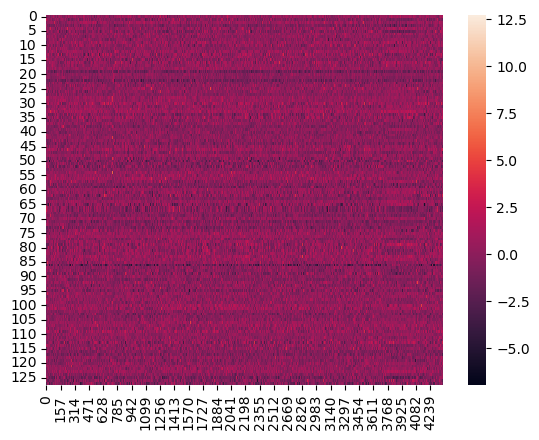

In [18]:
sns.heatmap(x, vmin=x.min(), vmax=x.max())


<Axes: >

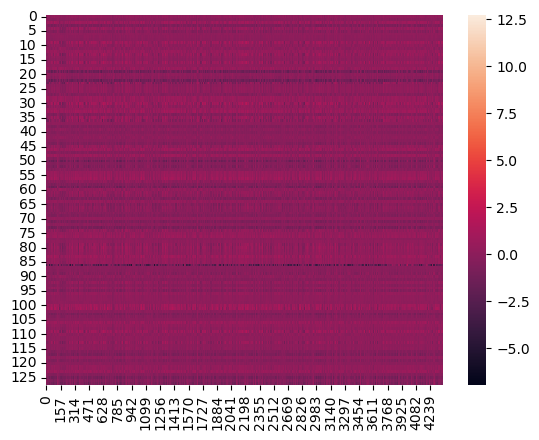

In [19]:
sns.heatmap(x_recon, vmin=x.min(), vmax=x.max())